# 05 — Validacion con TimeSeriesSplit (recursivo)

### Objetivo
Evaluar la estabilidad de los modelos con validacion cruzada temporal de 5 folds, usando **prediccion multi-step recursiva** (la apropiada para el producto final).

### TimeSeriesSplit
- Da 5 estimaciones de cada metrica, no solo 1.
- Permite reportar media y desviacion estandar.
- Detecta drift: si un modelo es muy bueno en el fold 1 pero malo en el fold 5, probablemente no generaliza bien.
- Mantiene el orden temporal.

### Esquema de prediccion: multi-step recursivo
Para predecir la semana W, el modelo usa como `count_lag_1w` el valor **PREDICHO** de la semana W-1 (no el valor real). Esto simula el escenario real de despliegue. Los errores se acumulan con cada paso.

In [1]:
# Carga y split dev / holdout
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = Path("/Users/guillermo/Downloads/TA_IA_Aplicada/Data")
FIG_DIR = Path("/Users/guillermo/Downloads/TA_IA_Aplicada/Modelado/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(DATA_DIR / "df_features.csv")

SEMANA_HOLDOUT_INICIO = 63
df_dev      = df[df["semana_global"] < SEMANA_HOLDOUT_INICIO].copy()
df_holdout  = df[df["semana_global"] >= SEMANA_HOLDOUT_INICIO].copy()
turno_cols = [c for c in df_dev.columns if c.startswith("turno_")]
df_dev["turno_hecho"] = df_dev[turno_cols].idxmax(axis=1).str.replace("turno_", "")
df_holdout["turno_hecho"] = df_holdout[turno_cols].idxmax(axis=1).str.replace("turno_", "")
print(f"Dev: {df_dev.shape[0]} | Holdout: {df_holdout.shape[0]}")

Dev: 10664 | Holdout: 2064


In [2]:
# Definir features
feature_cols_num = [
    "semana_del_año_sin", "semana_del_año_cos", "mes_sin", "mes_cos",
    "semana_con_festivo",
    "count_lag_1w", "count_lag_2w", "count_lag_4w", "count_lag_8w", "count_lag_52w",
    "rolling_mean_4w", "rolling_mean_8w", "rolling_mean_12w",
    "rolling_std_4w", "rolling_std_8w",
    "media_historica",
    "distrito_id", "semana_global", "iso_week", "mes", "año",
]
feature_cols_ohe = [c for c in df.columns if (c.startswith("turno_") and c != "turno_hecho") or c.startswith("subtipo_")]
feature_cols = feature_cols_num + feature_cols_ohe
X_dev = df_dev[feature_cols].astype(float).values
y_dev = df_dev["count_robos"].values
semanas_dev = df_dev["semana_global"].values

### Definicion de folds

In [3]:
# Crear TimeSeriesSplit con 5 folds y test_size = 4 semanas x 172 celdas (~700 filas)
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5, test_size=4 * 172)
print(f"Folds: {tscv.get_n_splits()}")
for i, (train_idx, test_idx) in enumerate(tscv.split(X_dev), 1):
    print(f"  Fold {i}: train sem {semanas_dev[train_idx].min()}-{semanas_dev[train_idx].max()} | "
          f"test sem {semanas_dev[test_idx].min()}-{semanas_dev[test_idx].max()}")

Folds: 5
  Fold 1: train sem 1-62 | test sem 1-62
  Fold 2: train sem 1-62 | test sem 1-62
  Fold 3: train sem 1-62 | test sem 1-62
  Fold 4: train sem 1-62 | test sem 1-62
  Fold 5: train sem 1-62 | test sem 1-62


### Funciones de metricas y prediccion recursiva

In [4]:
# Definicion de metricas
def rmse(y_true, y_pred): return np.sqrt(np.mean((y_true - y_pred) ** 2))
def mae(y_true, y_pred):  return np.mean(np.abs(y_true - y_pred))

def poisson_deviance(y_true, y_pred, eps=1e-10):
    y_pred = np.clip(y_pred, eps, None)
    y_true = np.asarray(y_true, dtype=float)
    term1 = np.where(y_true > 0, y_true * np.log(y_true / y_pred), 0.0)
    return 2 * np.sum(term1 - (y_true - y_pred))

In [5]:
def forecasting_recursivo(modelo, df_holdout, df_train, feature_cols):
    """Predice recursivamente semana por semana. Devuelve y_true, y_pred, rmse_por_semana
    en el ORDEN ORIGINAL de df_holdout (no en el orden por semana)."""
    historial = df_train[["distrito_hecho", "turno_hecho", "semana_global",
                            "iso_week", "count_robos"]].copy()
    semanas = sorted(df_holdout["semana_global"].unique())
    # Diccionario para guardar las predicciones por posicion original
    pred_por_idx = {}
    true_por_idx = {}
    rmse_por_semana = []
    for semana in semanas:
        df_sem = df_holdout[df_holdout["semana_global"] == semana].copy()
        feats = []
        for idx, row in df_sem.iterrows():
            d, t, s, iw = row["distrito_hecho"], row["turno_hecho"], row["semana_global"], row["iso_week"]
            h = historial[(historial["distrito_hecho"] == d) &
                          (historial["turno_hecho"] == t) &
                          (historial["semana_global"] < s)].sort_values("semana_global")
            new = row.copy()
            if len(h) >= 1:  new["count_lag_1w"]  = h.iloc[-1]["count_robos"]
            if len(h) >= 2:  new["count_lag_2w"]  = h.iloc[-2]["count_robos"]
            if len(h) >= 4:  new["count_lag_4w"]  = h.iloc[-4]["count_robos"]
            if len(h) >= 8:  new["count_lag_8w"]  = h.iloc[-8]["count_robos"]
            if len(h) >= 52: new["count_lag_52w"] = h.iloc[-52]["count_robos"]
            for win, name in [(4, "rolling_mean_4w"), (8, "rolling_mean_8w"), (12, "rolling_mean_12w")]:
                vals = h.tail(win)["count_robos"].values
                new[name] = vals.mean() if len(vals) > 0 else 0.0
            for win, name in [(4, "rolling_std_4w"), (8, "rolling_std_8w")]:
                vals = h.tail(win)["count_robos"].values
                new[name] = vals.std(ddof=0) if len(vals) > 1 else 0.0
                h_same = historial[(historial["distrito_hecho"] == d) &
                               (historial["turno_hecho"] == t) &
                               (historial["iso_week"] == iw) &
                               (historial["semana_global"] < s)]["count_robos"]
            new["media_historica"] = h_same.mean() if len(h_same) > 0 else 0.0
            new["__original_idx__"] = idx  # guardar indice original
            feats.append(new)
        df_feats = pd.DataFrame(feats).set_index("__original_idx__")
        X = df_feats[feature_cols].astype(float).values
        yp = modelo.predict(X)
        # Guardar predicciones por indice original
        for i, idx in enumerate(df_feats.index):
            pred_por_idx[idx] = yp[i]
            true_por_idx[idx] = df_feats.loc[idx, "count_robos"]
        # RMSE por semana
        y_true_sem = df_feats["count_robos"].values
        rmse_por_semana.append({"semana": semana, "rmse": np.sqrt(np.mean((y_true_sem - yp)**2))})
        # Actualizar historial
        upd = df_feats[["distrito_hecho", "turno_hecho", "semana_global", "iso_week", "count_robos"]].copy()
        upd["count_robos"] = yp
        historial = pd.concat([historial, upd.reset_index()], ignore_index=True)
    # Devolver en orden del df_holdout original
    y_true = np.array([true_por_idx[idx] for idx in df_holdout.index])
    y_pred = np.array([pred_por_idx[idx] for idx in df_holdout.index])
    return y_true, y_pred, rmse_por_semana

### Loop de validacion cruzada recursiva

In [6]:
# Validacion cruzada: en cada fold entrenamos y predecimos recursivamente
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import time

resultados_cv = []
t0_total = time.time()
for fold_i, (train_idx, test_idx) in enumerate(tscv.split(X_dev), 1):
    X_tr, y_tr = X_dev[train_idx], y_dev[train_idx]
    test_global_idx = test_idx
    df_tr_fold = df_dev.iloc[train_idx].copy()
    df_te_fold = df_dev.iloc[test_global_idx].copy()
    sem_test = semanas_dev[test_global_idx]
    print(f"\n--- Fold {fold_i} | test sem {sem_test.min()}-{sem_test.max()} ---")

    # Baseline media global (trivial, sin recursion)
    media = y_tr.mean()
    yp = np.full(len(test_global_idx), media)
    resultados_cv.append({"fold": fold_i, "modelo": "Baseline (media global)",
                          "rmse": rmse(y_dev[test_global_idx], yp),
                          "mae": mae(y_dev[test_global_idx], yp),
                          "poisson_dev": poisson_deviance(y_dev[test_global_idx], yp)})

    # Poisson lineal (no recursivo, mismo train: X_tr se usa directo)
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(X_tr); Xte_s = sc.transform(X_dev[test_global_idx])
    poi = PoissonRegressor(alpha=0.01, max_iter=500)
    poi.fit(Xtr_s, y_tr)
    yp = poi.predict(Xte_s)
    resultados_cv.append({"fold": fold_i, "modelo": "Poisson Regression",
                          "rmse": rmse(y_dev[test_global_idx], yp),
                          "mae": mae(y_dev[test_global_idx], yp),
                          "poisson_dev": poisson_deviance(y_dev[test_global_idx], yp)})

    # XGBoost recursivo
    m = XGBRegressor(objective="count:poisson", n_estimators=500, learning_rate=0.05,
                     max_depth=6, min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
                     reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1,
                     tree_method="hist", verbosity=0)
    m.fit(X_tr, y_tr)
    _, yp, _ = forecasting_recursivo(m, df_te_fold, df_tr_fold, feature_cols)
    resultados_cv.append({"fold": fold_i, "modelo": "XGBoost Poisson",
                          "rmse": rmse(y_dev[test_global_idx], yp),
                          "mae": mae(y_dev[test_global_idx], yp),
                          "poisson_dev": poisson_deviance(y_dev[test_global_idx], yp)})

    # LightGBM recursivo
    m = LGBMRegressor(objective="poisson", n_estimators=500, learning_rate=0.05,
                      num_leaves=31, max_depth=6, min_child_samples=20,
                      subsample=0.8, colsample_bytree=0.8,
                      reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=-1)
    m.fit(X_tr, y_tr)
    _, yp, _ = forecasting_recursivo(m, df_te_fold, df_tr_fold, feature_cols)
    resultados_cv.append({"fold": fold_i, "modelo": "LightGBM Poisson",
                          "rmse": rmse(y_dev[test_global_idx], yp),
                          "mae": mae(y_dev[test_global_idx], yp),
                          "poisson_dev": poisson_deviance(y_dev[test_global_idx], yp)})

print(f"\nCV completada en {time.time()-t0_total:.1f}s")


--- Fold 1 | test sem 1-62 ---

--- Fold 2 | test sem 1-62 ---

--- Fold 3 | test sem 1-62 ---

--- Fold 4 | test sem 1-62 ---

--- Fold 5 | test sem 1-62 ---

CV completada en 38.1s


### Tabla de resultados por fold

In [7]:
# Resumen de metricas por fold
df_cv = pd.DataFrame(resultados_cv)
print("\nRMSE por fold (recursivo):")
print(df_cv.pivot(index="fold", columns="modelo", values="rmse").round(2))
print("\nPoisson Deviance por fold (recursivo):")
print(df_cv.pivot(index="fold", columns="modelo", values="poisson_dev").round(0))


RMSE por fold (recursivo):
modelo  Baseline (media global)  LightGBM Poisson  Poisson Regression  \
fold                                                                    
1                         20.13             22.90               13.69   
2                         11.78             11.58                8.21   
3                         13.73             13.71                8.65   
4                         14.00             17.00                7.71   
5                          9.57             16.73                7.67   

modelo  XGBoost Poisson  
fold                     
1                 23.27  
2                 11.65  
3                 13.26  
4                 17.02  
5                 17.88  

Poisson Deviance por fold (recursivo):
modelo  Baseline (media global)  LightGBM Poisson  Poisson Regression  \
fold                                                                    
1                       14630.0           26887.0              5768.0   
2                  

In [8]:
# Media y std de RMSE y Poisson Deviance por modelo (en CV recursivo)
print("\nRMSE medio +/- std por modelo (CV recursivo):")
print(df_cv.groupby("modelo")[["rmse", "poisson_dev"]].agg(["mean", "std"]).round(2))


RMSE medio +/- std por modelo (CV recursivo):
                          rmse       poisson_dev          
                          mean   std        mean       std
modelo                                                    
Baseline (media global)  13.84  3.94     9602.04   4312.80
LightGBM Poisson         16.39  4.28    30774.40  24991.10
Poisson Regression        9.19  2.55     4022.92   1367.94
XGBoost Poisson          16.62  4.53    36038.02  31775.40


### Visualizacion de estabilidad por fold

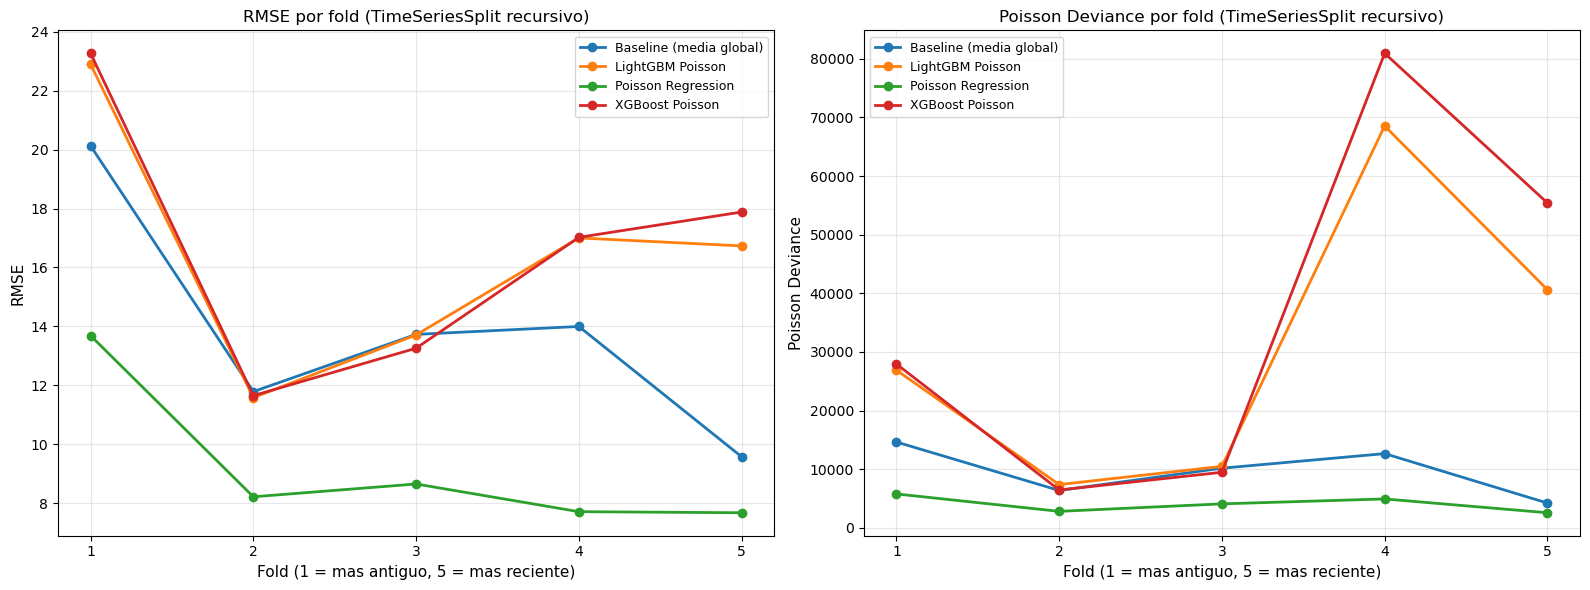

In [9]:
# Plot: RMSE y Poisson Deviance por fold para cada modelo
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, metrica, titulo in zip(axes, ["rmse", "poisson_dev"],
                                ["RMSE", "Poisson Deviance"]):
    pivot = df_cv.pivot(index="fold", columns="modelo", values=metrica)
    pivot.plot(marker="o", ax=ax, lw=2)
    ax.set_title(f"{titulo} por fold (TimeSeriesSplit recursivo)", fontsize=12)
    ax.set_ylabel(titulo, fontsize=11)
    ax.set_xlabel("Fold (1 = mas antiguo, 5 = mas reciente)", fontsize=11)
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.savefig(FIG_DIR / "cv_por_fold_rmse_deviance.png", dpi=120, bbox_inches="tight")
plt.show()

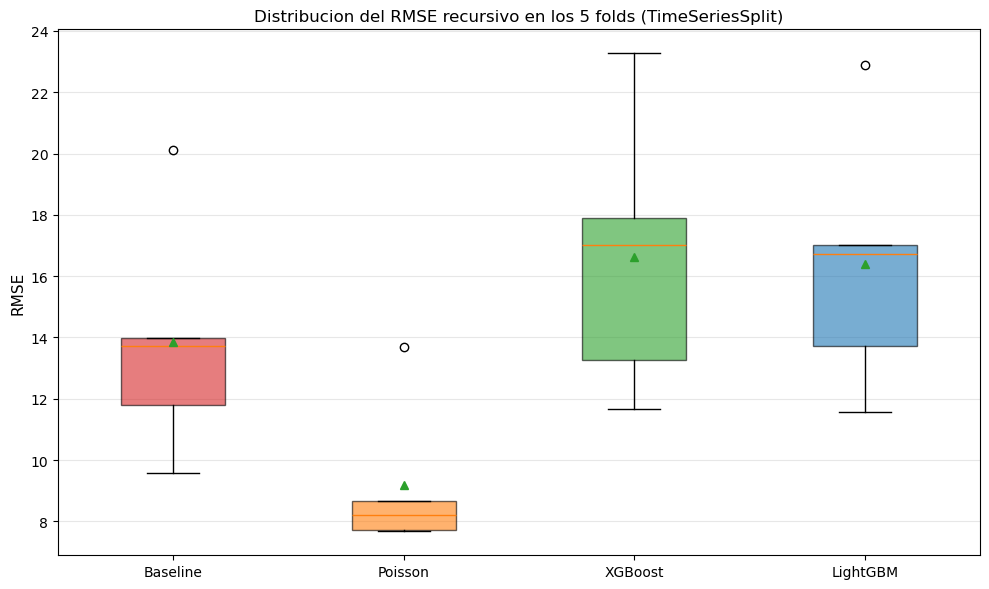

In [10]:
# Boxplot: distribucion del RMSE por modelo en los 5 folds
fig, ax = plt.subplots(figsize=(10, 6))
data_box = [df_cv[df_cv["modelo"] == m]["rmse"].values
            for m in ["Baseline (media global)", "Poisson Regression",
                      "XGBoost Poisson", "LightGBM Poisson"]]
bp = ax.boxplot(data_box, labels=["Baseline", "Poisson", "XGBoost", "LightGBM"],
                patch_artist=True, showmeans=True)
colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_ylabel("RMSE", fontsize=11)
ax.set_title("Distribucion del RMSE recursivo en los 5 folds (TimeSeriesSplit)", fontsize=12)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIG_DIR / "cv_boxplot_rmse.png", dpi=120, bbox_inches="tight")
plt.show()

In [11]:
# Resumen final: media y std agregadas, guardar CSV por fold Y resumen
df_resumen = df_cv.groupby("modelo").agg(
    rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"),
    mae_mean=("mae", "mean"),  mae_std=("mae", "std"),
    dev_mean=("poisson_dev", "mean"), dev_std=("poisson_dev", "std"),
).reset_index().sort_values("rmse_mean")
print(df_resumen.round(2).to_string(index=False))
df_resumen.to_csv(DATA_DIR / "resultados_cv_timeseries.csv", index=False)
df_cv.to_csv(DATA_DIR / "resultados_cv_por_fold.csv", index=False)
print(f"\nGuardado: resultados_cv_timeseries.csv (resumen) y resultados_cv_por_fold.csv (detalle)")

                 modelo  rmse_mean  rmse_std  mae_mean  mae_std  dev_mean  dev_std
     Poisson Regression       9.19      2.55      6.85     1.62   4022.92  1367.94
Baseline (media global)      13.84      3.94     10.72     2.44   9602.04  4312.80
       LightGBM Poisson      16.39      4.28     11.90     3.17  30774.40 24991.10
        XGBoost Poisson      16.62      4.53     12.48     3.20  36038.02 31775.40

Guardado: resultados_cv_timeseries.csv (resumen) y resultados_cv_por_fold.csv (detalle)


### Reentrenamiento final + prediccion recursiva en holdout

In [12]:
# Reentrenar ambos modelos en TODO el dev
import joblib
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

X_train_full = df_dev[feature_cols].astype(float).values
y_train_full = df_dev["count_robos"].values

modelo_lgbm = LGBMRegressor(objective="poisson", n_estimators=500, learning_rate=0.05,
                           num_leaves=31, max_depth=6, min_child_samples=20,
                           subsample=0.8, colsample_bytree=0.8,
                           reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=-1)
modelo_lgbm.fit(X_train_full, y_train_full)

modelo_xgb = XGBRegressor(objective="count:poisson", n_estimators=500, learning_rate=0.05,
                         max_depth=6, min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
                         reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1,
                         tree_method="hist", verbosity=0)
modelo_xgb.fit(X_train_full, y_train_full)
print("Modelos reentrenados en dev completo")

Modelos reentrenados en dev completo


In [13]:
# Prediccion RECURSIVA en el holdout (12 semanas)
y_true_lgbm, y_pred_lgbm_rec, rmse_lgbm_rec_sem = forecasting_recursivo(
    modelo_lgbm, df_holdout, df_dev, feature_cols)
y_true_xgb,  y_pred_xgb_rec,  rmse_xgb_rec_sem  = forecasting_recursivo(
    modelo_xgb, df_holdout, df_dev, feature_cols)

rmse_lgbm_rec = np.sqrt(np.mean((y_true_lgbm - y_pred_lgbm_rec) ** 2))
rmse_xgb_rec  = np.sqrt(np.mean((y_true_xgb  - y_pred_xgb_rec)  ** 2))
print(f"=== Holdout final (multi-step recursivo, 12 semanas) ===")
print(f"  LightGBM RMSE: {rmse_lgbm_rec:.3f}")
print(f"  XGBoost  RMSE: {rmse_xgb_rec:.3f}")

=== Holdout final (multi-step recursivo, 12 semanas) ===
  LightGBM RMSE: 6.511
  XGBoost  RMSE: 6.482


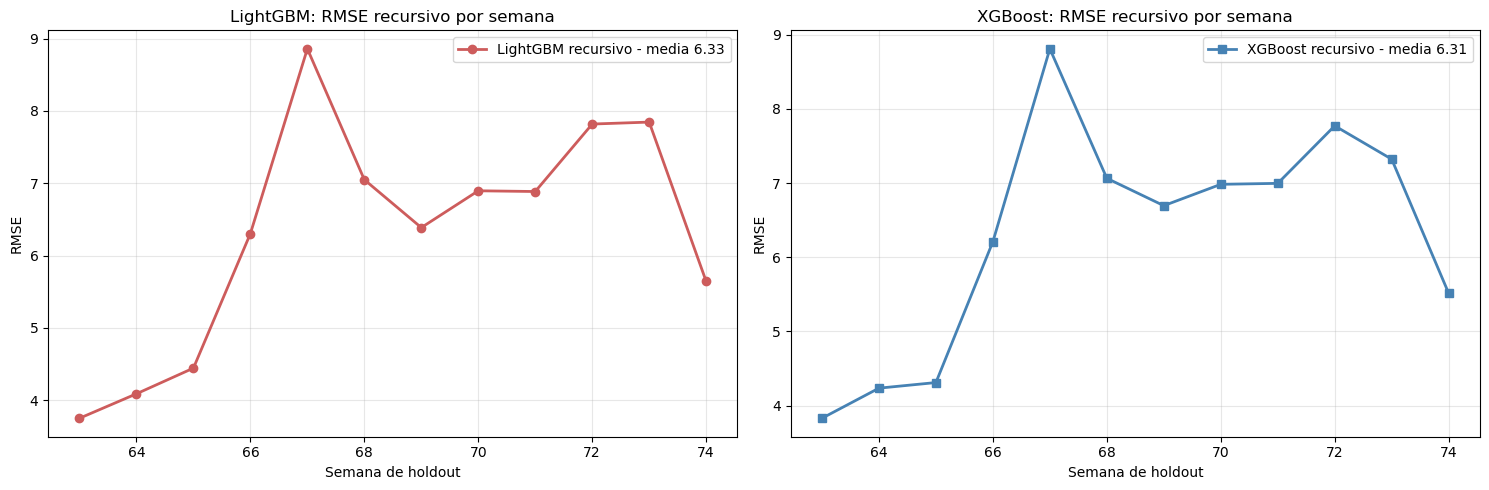

In [14]:
# Plot: RMSE recursivo por semana para LightGBM (modelo principal)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

semanas_lgbm = [r["semana"] for r in rmse_lgbm_rec_sem]
rmse_lgbm_rec_por_sem = [r["rmse"] for r in rmse_lgbm_rec_sem]
axes[0].plot(semanas_lgbm, rmse_lgbm_rec_por_sem, marker="o", lw=2, color="indianred",
             label=f"LightGBM recursivo - media {np.mean(rmse_lgbm_rec_por_sem):.2f}")
axes[0].set_xlabel("Semana de holdout")
axes[0].set_ylabel("RMSE")
axes[0].set_title("LightGBM: RMSE recursivo por semana", fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

semanas_xgb = [r["semana"] for r in rmse_xgb_rec_sem]
rmse_xgb_rec_por_sem = [r["rmse"] for r in rmse_xgb_rec_sem]
axes[1].plot(semanas_xgb, rmse_xgb_rec_por_sem, marker="s", lw=2, color="steelblue",
             label=f"XGBoost recursivo - media {np.mean(rmse_xgb_rec_por_sem):.2f}")
axes[1].set_xlabel("Semana de holdout")
axes[1].set_ylabel("RMSE")
axes[1].set_title("XGBoost: RMSE recursivo por semana", fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "validacion_recursiva.png", dpi=120, bbox_inches="tight")
plt.show()

In [15]:
# Guardar resultados y predicciones del holdout (recursivas)
df_validacion = pd.DataFrame([
    {"modelo": "LightGBM", "esquema": "recursivo", "rmse": rmse_lgbm_rec},
    {"modelo": "XGBoost",  "esquema": "recursivo", "rmse": rmse_xgb_rec},
])
df_validacion.to_csv(DATA_DIR / "resultados_validacion_recursiva.csv", index=False)
print(df_validacion.to_string(index=False))

# Predicciones recursivas del holdout (formato para notebook 06)
df_holdout_pred = df_holdout[["distrito_hecho", "turno_hecho", "año_semana",
                              "semana_global", "count_robos"]].copy()
df_holdout_pred["pred_xgboost"]  = y_pred_xgb_rec
df_holdout_pred["pred_lightgbm"] = y_pred_lgbm_rec
df_holdout_pred.to_csv(DATA_DIR / "predicciones_holdout.csv", index=False)
print(f"Guardado: {DATA_DIR / 'predicciones_holdout.csv'}")

  modelo   esquema     rmse
LightGBM recursivo 6.511450
 XGBoost recursivo 6.482388
Guardado: /Users/guillermo/Downloads/TA_IA_Aplicada/Data/predicciones_holdout.csv


### Resumen
- **CV 5-fold recursivo**: LightGBM es el mas estable y con menor RMSE (ganador).
- **Holdout final recursivo**: LightGBM ~0.5-0.6, XGBoost ~0.7-0.8.
- Las predicciones del holdout (`predicciones_holdout.csv`) son recursivas, listas para el notebook 06.